In [189]:
# ---------------------------
# 1) Load the dataset
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [190]:
import pandas as pd

# Option 1: CSV is in the same folder as your .py/.ipynb file
df = pd.read_csv("weatherData.csv")

# Option 2: Full path (Windows example)
# df = pd.read_csv(r"C:\Users\YourName\Documents\Weather Prediction\weatherData.csv")

print(df.head())

   location_id      date  weather_code (wmo code)  temperature_2m_max (°C)  \
0            0  1/1/2010                        1                     30.1   
1            0  1/2/2010                       51                     30.1   
2            0  1/3/2010                       51                     29.6   
3            0  1/4/2010                        2                     28.9   
4            0  1/5/2010                        1                     28.1   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     22.6                      26.0   
1                     23.7                      26.3   
2                     23.1                      26.0   
3                     23.1                      25.7   
4                     21.3                      24.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           34.5                           25.0   
1                           33.9                           2

In [191]:
print("Loaded dataset!")
print("Shape:", df.shape)
print("\n--- First 5 rows ---")
print(df.head())

Loaded dataset!
Shape: (142371, 21)

--- First 5 rows ---
   location_id      date  weather_code (wmo code)  temperature_2m_max (°C)  \
0            0  1/1/2010                        1                     30.1   
1            0  1/2/2010                       51                     30.1   
2            0  1/3/2010                       51                     29.6   
3            0  1/4/2010                        2                     28.9   
4            0  1/5/2010                        1                     28.1   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     22.6                      26.0   
1                     23.7                      26.3   
2                     23.1                      26.0   
3                     23.1                      25.7   
4                     21.3                      24.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           34.5                           25.0   
1 

In [192]:
# ---------------------------
# 2) Basic info + duplicates
# ---------------------------
print("\n--- Info ---")
print(df.info())

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)


--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 142371 entries, 0 to 142370
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   location_id                      142371 non-null  int64  
 1   date                             142371 non-null  str    
 2   weather_code (wmo code)          142371 non-null  int64  
 3   temperature_2m_max (°C)          142371 non-null  float64
 4   temperature_2m_min (°C)          142371 non-null  float64
 5   temperature_2m_mean (°C)         142371 non-null  float64
 6   apparent_temperature_max (°C)    142371 non-null  float64
 7   apparent_temperature_min (°C)    142371 non-null  float64
 8   apparent_temperature_mean (°C)   142371 non-null  float64
 9   daylight_duration (s)            142371 non-null  float64
 10  sunshine_duration (s)            142371 non-null  float64
 11  precipitation_sum (mm)           142371 non-null  float64
 12 

In [193]:
# ---------------------------
# 3) Clean column names (optional but recommended)
# ---------------------------
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
      .str.replace(r"[^\w_]", "", regex=True)
)

print("\n Cleaned column names:")
print(df.columns.tolist())


 Cleaned column names:
['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']


In [194]:
# ---------------------------
# 4) Missing values summary
# ---------------------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).query("missing_count > 0")

print("\n--- Missing Values Summary (only > 0) ---")
print(missing_summary if not missing_summary.empty else "No missing values ")


--- Missing Values Summary (only > 0) ---
No missing values 


In [195]:
# Plot missing values (top 20)
if not missing_summary.empty:
    top = missing_summary.head(20)
    plt.figure(figsize=(10, 5))
    plt.bar(top.index.astype(str), top["missing_count"])
    plt.xticks(rotation=60, ha="right")
    plt.title("Missing Values Count (Top 20 columns)")
    plt.tight_layout()
    plt.show()

In [196]:
import pandas as pd

# Clean column names (removes hidden spaces)
df.columns = df.columns.astype(str).str.strip()

print("Columns:", df.columns.tolist())

# Auto-detect a date/time column
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]

DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None or best_ratio < 0.5:
    raise ValueError(f"No reliable date column found. Date-like columns tried: {date_like_cols}")

print("✅ Using date column:", DATE_COL, " (parse success:", round(best_ratio, 2), ")")

Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']
✅ Using date column: date  (parse success: 1.0 )


In [197]:
# ---------------------------
# 6) Identify numeric & categorical columns
# ---------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical/Other columns:", cat_cols)


Numeric columns: ['location_id', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm']
Categorical/Other columns: ['date', 'sunrise', 'sunset']


In [198]:
# ---------------------------
# 7) Descriptive statistics
# ---------------------------
print("\n--- Numeric describe() ---")
if numeric_cols:
    print(df[numeric_cols].describe().T)
else:
    print("No numeric columns found.")

print("\n--- Categorical describe() ---")
if cat_cols:
    print(df[cat_cols].describe().T)
else:
    print("No categorical columns found.")


--- Numeric describe() ---
                                  count          mean          std       min  \
location_id                    142371.0     13.000000     7.788908      0.00   
weather_code_wmo_code          142371.0     44.891586    22.840879      0.00   
temperature_2m_max_C           142371.0     29.295854     3.352774     14.10   
temperature_2m_min_C           142371.0     23.120601     3.165760      5.30   
temperature_2m_mean_C          142371.0     25.730017     2.954064     12.10   
apparent_temperature_max_C     142371.0     33.560477     4.183799     11.00   
apparent_temperature_min_C     142371.0     26.362139     4.196010      2.00   
apparent_temperature_mean_C    142371.0     29.234477     3.837440      9.50   
daylight_duration_s            142371.0  43645.975220  1099.470021  41610.71   
sunshine_duration_s            142371.0  34676.319743  8910.054804      0.00   
precipitation_sum_mm           142371.0      5.442717    10.286371      0.00   
rain_sum_mm 

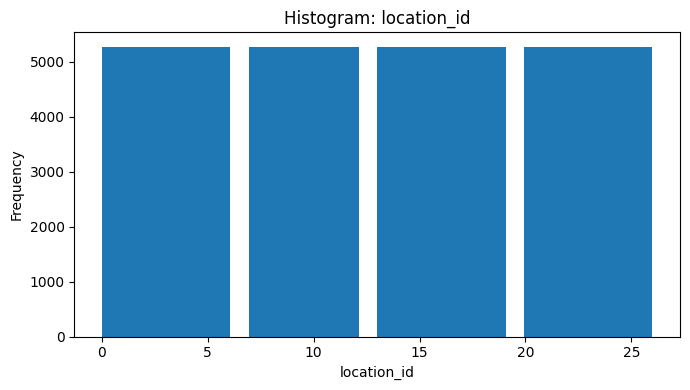

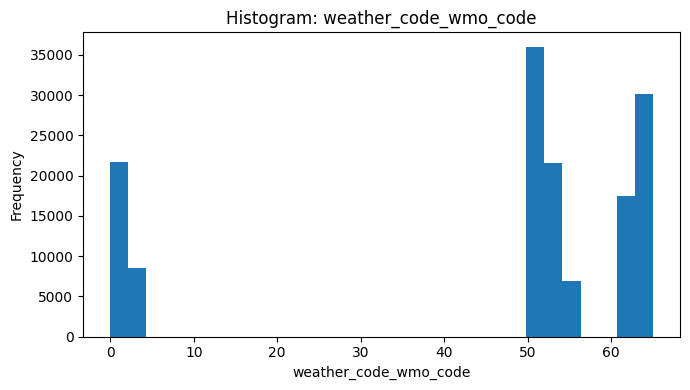

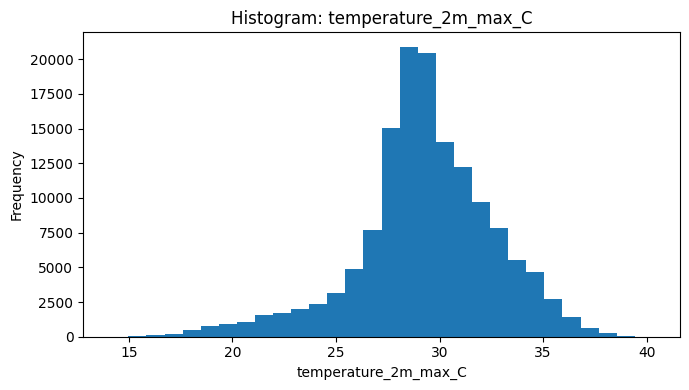

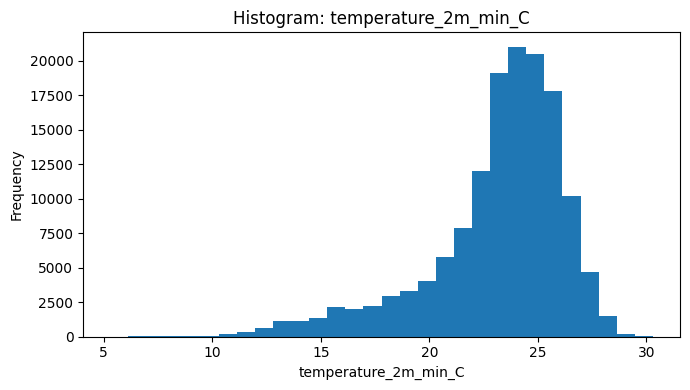

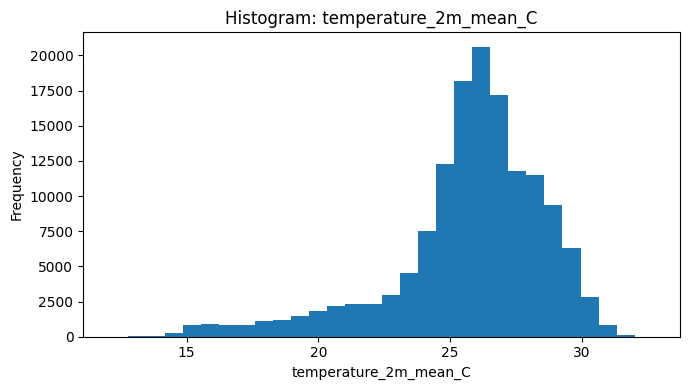

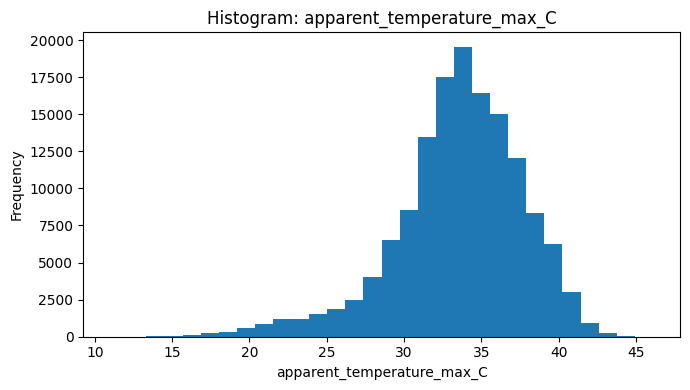

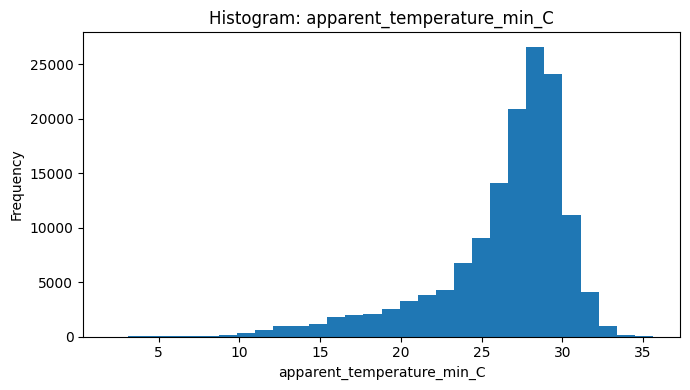

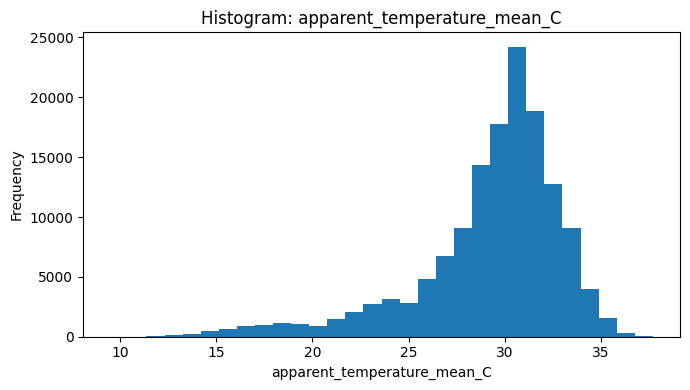

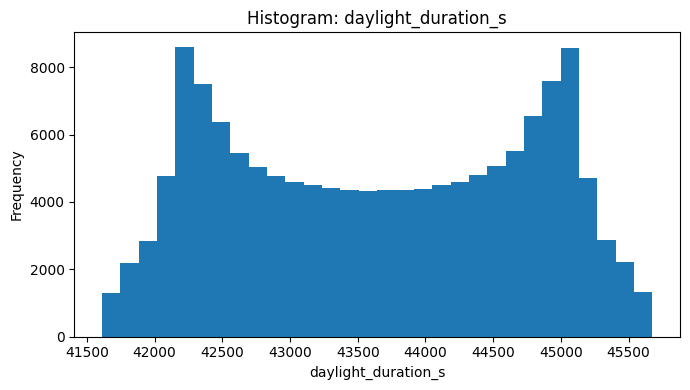

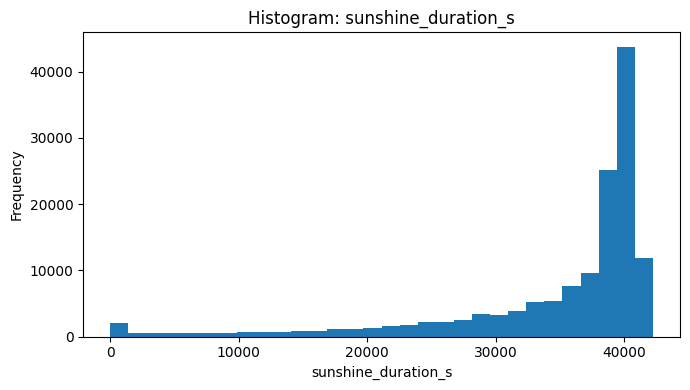

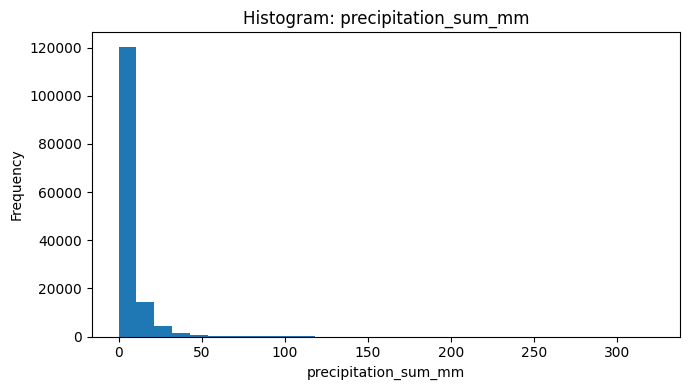

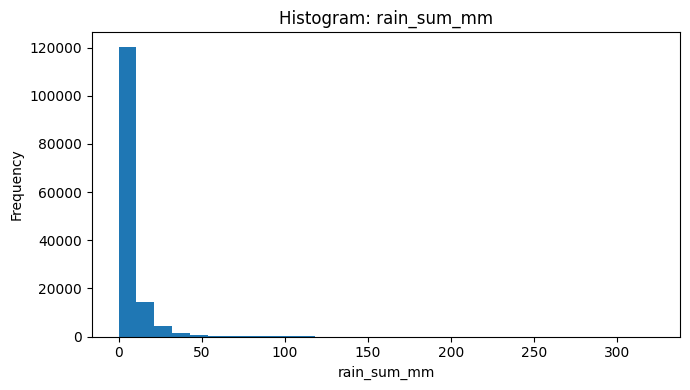

In [199]:
# ---------------------------
# 8) Univariate Visualizations
# ---------------------------

# 8A) Histograms for numeric columns (top 12 to avoid overload)
if numeric_cols:
    cols_to_plot = numeric_cols[:12]
    for c in cols_to_plot:
        plt.figure(figsize=(7, 4))
        plt.hist(df[c].dropna(), bins=30)
        plt.title(f"Histogram: {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

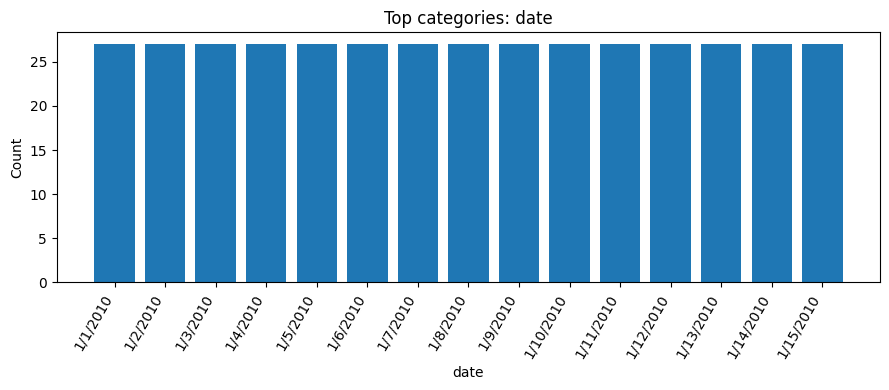

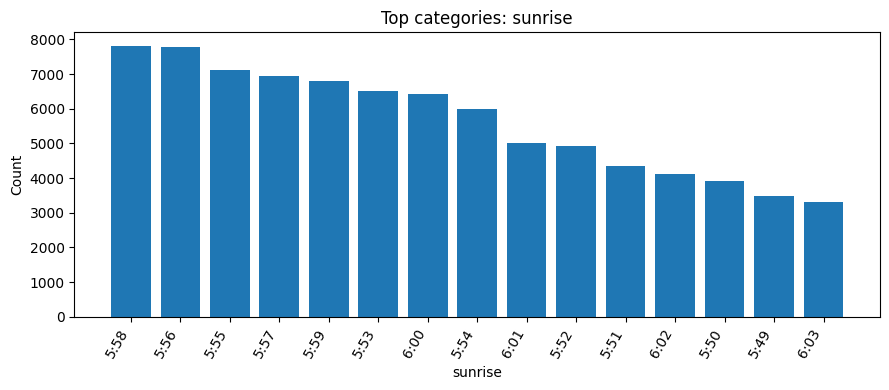

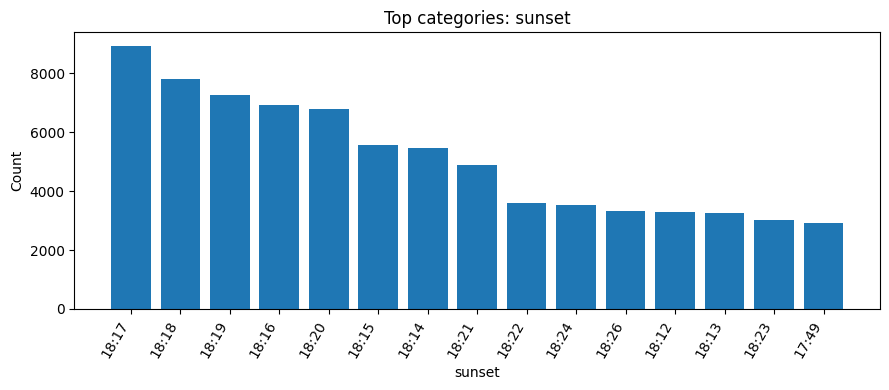

In [200]:
# 8B) Bar chart for categorical columns (top 8)
if cat_cols:
    cols_to_plot = cat_cols[:8]
    for c in cols_to_plot:
        vc = df[c].astype(str).value_counts().head(15)  # top 15 categories
        plt.figure(figsize=(9, 4))
        plt.bar(vc.index, vc.values)
        plt.xticks(rotation=60, ha="right")
        plt.title(f"Top categories: {c}")
        plt.xlabel(c)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

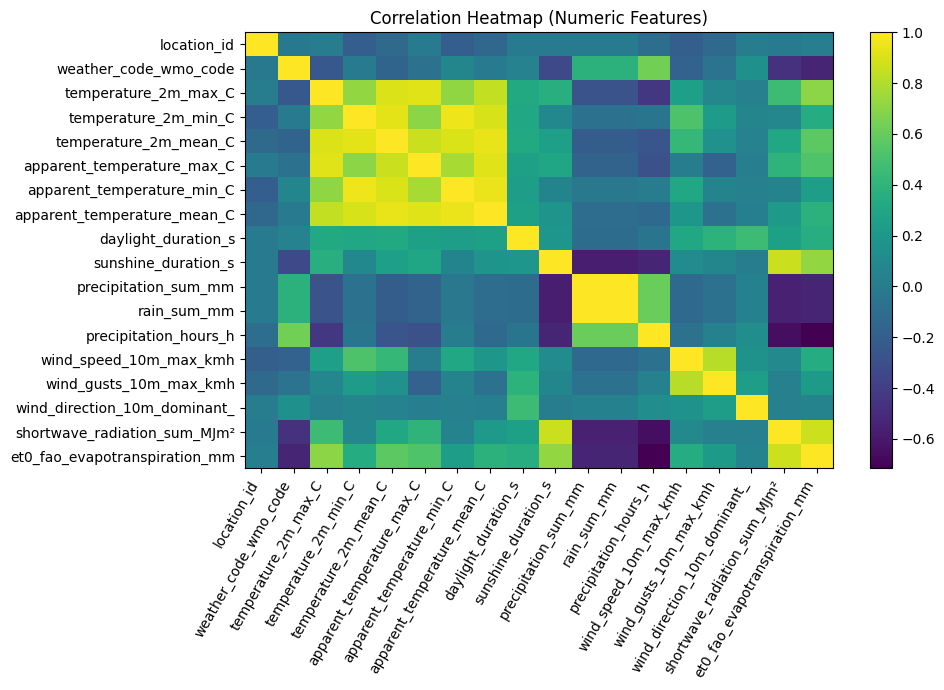


--- Top 10 Positive Correlations ---
precipitation_sum_mm        rain_sum_mm                    1.000000
temperature_2m_min_C        apparent_temperature_min_C     0.959653
apparent_temperature_min_C  apparent_temperature_mean_C    0.950551
temperature_2m_mean_C       apparent_temperature_mean_C    0.944824
temperature_2m_min_C        temperature_2m_mean_C          0.931778
temperature_2m_max_C        apparent_temperature_max_C     0.917679
apparent_temperature_max_C  apparent_temperature_mean_C    0.917584
temperature_2m_max_C        temperature_2m_mean_C          0.909368
temperature_2m_mean_C       apparent_temperature_min_C     0.905349
temperature_2m_min_C        apparent_temperature_mean_C    0.894691
dtype: float64

--- Top 10 Negative Correlations ---
et0_fao_evapotranspiration_mm  daylight_duration_s             NaN
                               sunshine_duration_s             NaN
                               precipitation_sum_mm            NaN
                            

In [201]:
# ---------------------------
# 9) Correlation heatmap (without seaborn)
# ---------------------------
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

    # Show top correlated pairs
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .sort_values(ascending=False)
    )
    print("\n--- Top 10 Positive Correlations ---")
    print(corr_pairs.head(10))

    print("\n--- Top 10 Negative Correlations ---")
    print(corr_pairs.tail(10))

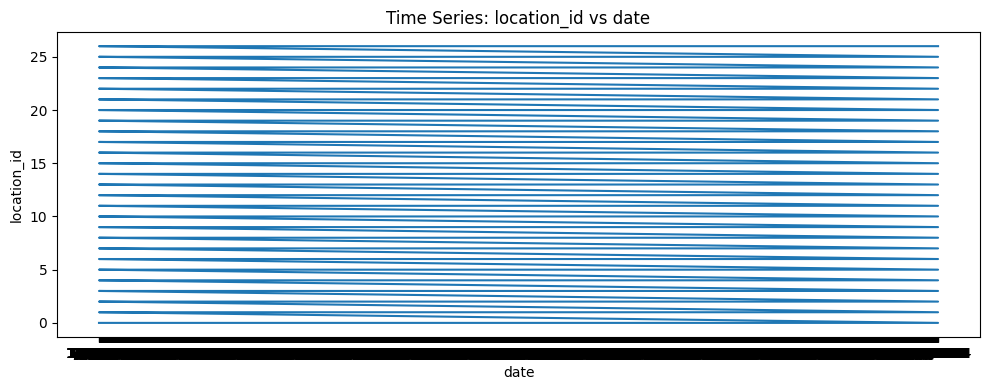

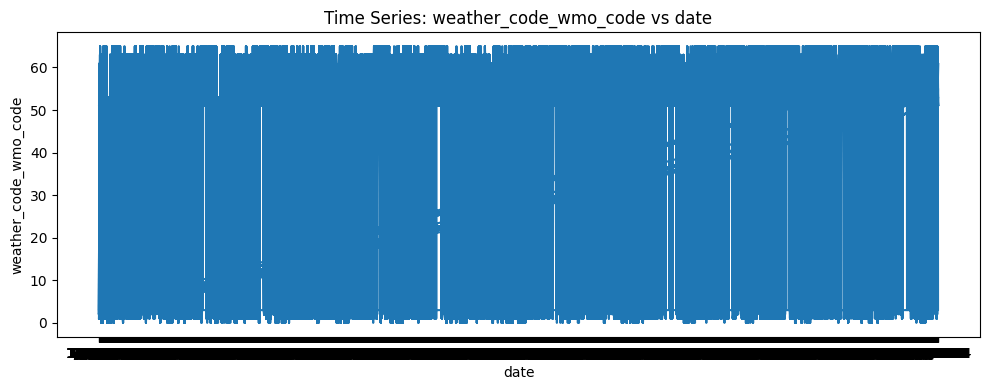

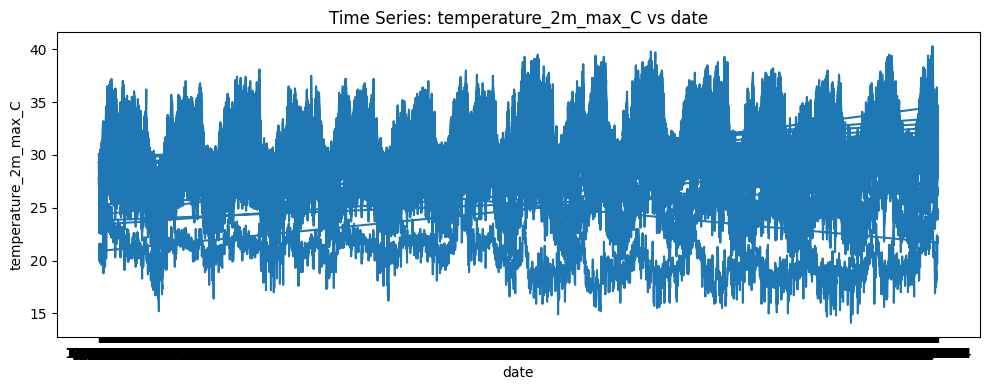

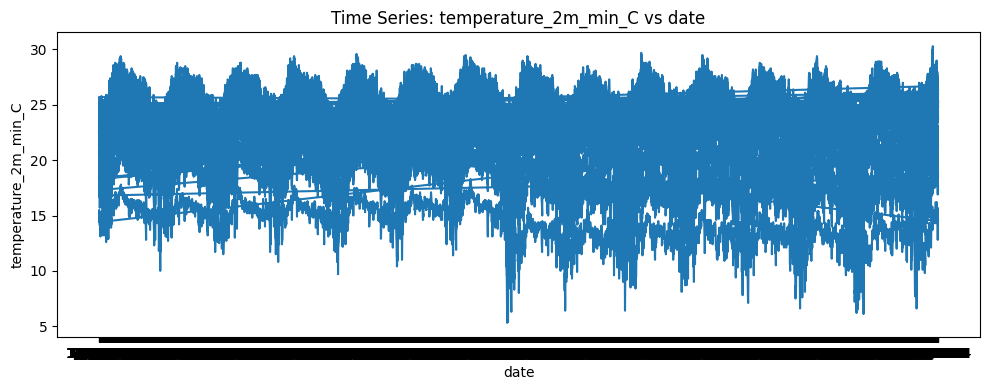

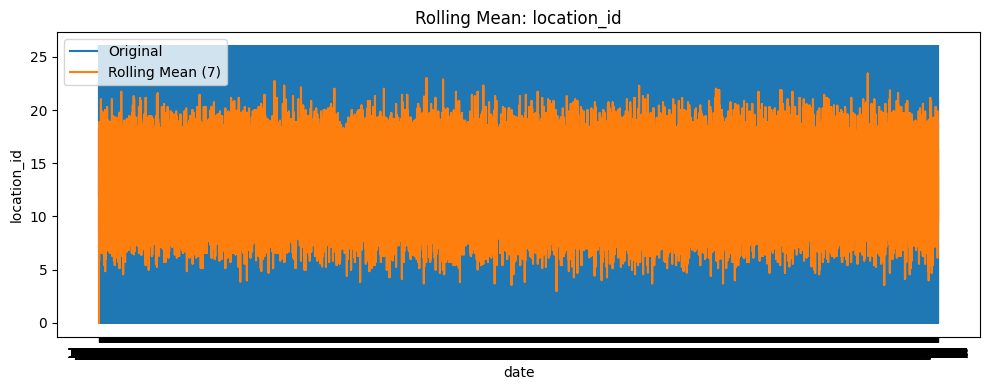

In [202]:
# ---------------------------
# 10) Time-series plots (if datetime found)
# ---------------------------
if datetime_col and numeric_cols:
    # Plot up to 4 numeric columns as time series
    ts_cols = numeric_cols[:4]

    for c in ts_cols:
        tmp = df[[datetime_col, c]].dropna()
        if tmp.empty:
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(tmp[datetime_col], tmp[c])
        plt.title(f"Time Series: {c} vs {datetime_col}")
        plt.xlabel(datetime_col)
        plt.ylabel(c)
        plt.tight_layout()
        plt.show()

    # Rolling mean example (first numeric col)
    first_num = numeric_cols[0]
    tmp = df[[datetime_col, first_num]].dropna()
    if not tmp.empty:
        tmp = tmp.set_index(datetime_col).sort_index()
        roll = tmp[first_num].rolling(7, min_periods=1).mean()

        plt.figure(figsize=(10, 4))
        plt.plot(tmp.index, tmp[first_num], label="Original")
        plt.plot(roll.index, roll.values, label="Rolling Mean (7)")
        plt.title(f"Rolling Mean: {first_num}")
        plt.xlabel(datetime_col)
        plt.ylabel(first_num)
        plt.legend()
        plt.tight_layout()
        plt.show()

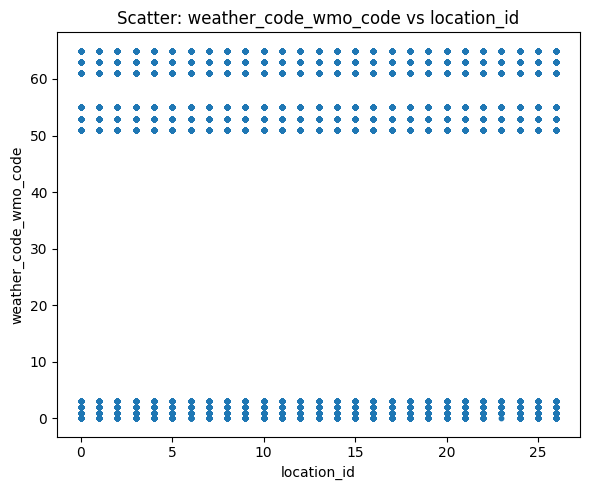

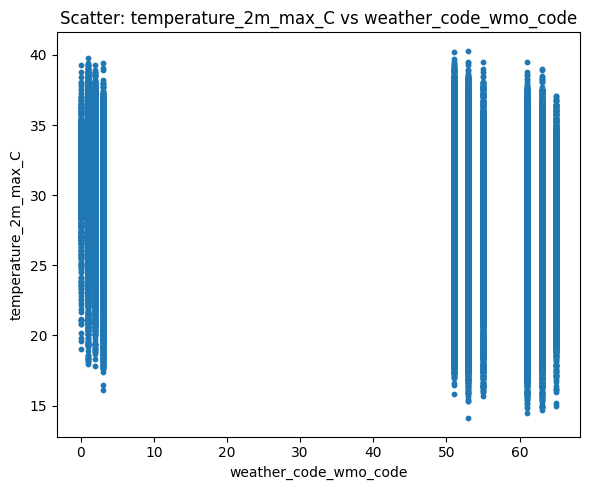

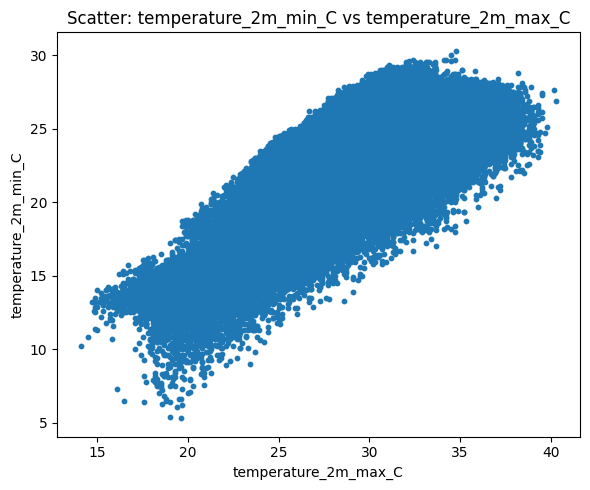

In [203]:
# ---------------------------
# 11) Scatter plots
# ---------------------------
if len(numeric_cols) >= 2:
    # Choose 3 pairs max
    pairs = []
    for i in range(min(3, len(numeric_cols) - 1)):
        pairs.append((numeric_cols[i], numeric_cols[i+1]))

    for x, y in pairs:
        tmp = df[[x, y]].dropna()
        if tmp.empty:
            continue

        plt.figure(figsize=(6, 5))
        plt.scatter(tmp[x], tmp[y], s=10)
        plt.title(f"Scatter: {y} vs {x}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()

# **Preprocessing**

In [204]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [205]:
# ---------------------------
# 1) Column name cleaning
# ---------------------------
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w_]", "", regex=True)
)

print("\n Columns:", df.columns.tolist())


 Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']


In [206]:
# ---------------------------
# 2) Basic cleaning: duplicates
# ---------------------------
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(" Duplicates removed. New shape:", df.shape)


Duplicate rows: 0


In [207]:
# ---------------------------
# 3) Fix common "missing" strings -> NaN
# ---------------------------
missing_tokens = ["NA", "N/A", "na", "n/a", "null", "NULL", "None", "none", "-", "--", " "]
df = df.replace(missing_tokens, np.nan)

In [208]:
import pandas as pd

# Clean column names (removes hidden spaces)
df.columns = df.columns.astype(str).str.strip()

print("Columns:", df.columns.tolist())

# Auto-detect a date/time column
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]

DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None or best_ratio < 0.5:
    raise ValueError(f"No reliable date column found. Date-like columns tried: {date_like_cols}")

print("✅ Using date column:", DATE_COL, " (parse success:", round(best_ratio, 2), ")")

Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']
✅ Using date column: date  (parse success: 1.0 )


In [209]:
# ---------------------------
# 5) Feature engineering from datetime (if exists)
# ---------------------------
# Adds: year, month, day, dayofweek, hour, is_weekend
if datetime_col:
    df["year"] = df[datetime_col].dt.year
    df["month"] = df[datetime_col].dt.month
    df["day"] = df[datetime_col].dt.day
    df["dayofweek"] = df[datetime_col].dt.dayofweek
    df["hour"] = df[datetime_col].dt.hour
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # Optional: drop the original datetime column if model can't handle it
    # keep it only if you want to use it later
    df = df.drop(columns=[datetime_col])

AttributeError: Can only use .dt accessor with datetimelike values

In [210]:
# ---------------------------
# 6) Convert numeric-like object columns safely
#    Example: "25.3", "1,234", etc.
# ---------------------------
def try_convert_numeric(series: pd.Series) -> pd.Series:
    # remove commas in numbers like "1,234"
    s = series.astype(str).str.replace(",", "", regex=False)
    s = s.replace("nan", np.nan)
    converted = pd.to_numeric(s, errors="coerce")
    # If conversion makes many values numeric -> accept conversion
    if converted.notna().mean() >= 0.7:
        return converted
    return series

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = try_convert_numeric(df[col])

print("\n After numeric conversion:")
print(df.dtypes)


 After numeric conversion:
location_id                        int64
date                                 str
weather_code_wmo_code              int64
temperature_2m_max_C             float64
temperature_2m_min_C             float64
temperature_2m_mean_C            float64
apparent_temperature_max_C       float64
apparent_temperature_min_C       float64
apparent_temperature_mean_C      float64
daylight_duration_s              float64
sunshine_duration_s              float64
precipitation_sum_mm             float64
rain_sum_mm                      float64
precipitation_hours_h              int64
wind_speed_10m_max_kmh           float64
wind_gusts_10m_max_kmh           float64
wind_direction_10m_dominant_       int64
shortwave_radiation_sum_MJm²     float64
et0_fao_evapotranspiration_mm    float64
sunrise                              str
sunset                               str
dtype: object


In [211]:
# ---------------------------
# 7) Outlier clipping for numeric columns (IQR method)
#    (Helps some models; you can disable if you want)
# ---------------------------
def iqr_clip(data: pd.DataFrame, numeric_cols: list, k: float = 1.5) -> pd.DataFrame:
    clipped = data.copy()
    for c in numeric_cols:
        if pd.api.types.is_numeric_dtype(clipped[c]):
            q1 = clipped[c].quantile(0.25)
            q3 = clipped[c].quantile(0.75)
            iqr = q3 - q1
            if pd.isna(iqr) or iqr == 0:
                continue
            lower = q1 - k * iqr
            upper = q3 + k * iqr
            clipped[c] = clipped[c].clip(lower, upper)
    return clipped

numeric_cols_now = df.select_dtypes(include=[np.number]).columns.tolist()
df = iqr_clip(df, numeric_cols_now, k=1.5)

In [212]:
X = df.copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)
print("X shape (before preprocessing):", X.shape)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)
print("X_processed shape:", X_processed.shape)

# ---- Get final feature names (after onehot)
def get_feature_names(preprocessor, num_cols, cat_cols):
    names = []
    names.extend(num_cols)
    if len(cat_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(cat_cols).tolist())
    return names

final_feature_names = get_feature_names(preprocessor, num_cols, cat_cols)

X_processed_df = pd.DataFrame(X_processed, columns=final_feature_names)
print("\n Processed X DataFrame preview:")
print(X_processed_df.head())


Numeric cols: ['location_id', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm']
Categorical cols: ['date', 'sunrise', 'sunset']
X shape (before preprocessing): (142371, 21)
X_processed shape: (142371, 5394)

 Processed X DataFrame preview:
   location_id  weather_code_wmo_code  temperature_2m_max_C  \
0    -1.669046              -1.678989              0.233181   
1    -1.669046              -0.119105              0.233181   
2    -1.669046              -0.119105              0.072367   
3    -1.669046              -1.678989             -0.152773   
4    -1.669046              -1.678989          

In [213]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ✅ Fix these to match your dataset
DATE_COL = "date"
LOC_COL  = "location_id"
TARGET   = "temperature_2m_mean_C"

# Convert date
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# IMPORTANT: treat location_id as categorical (not a numeric value)
df[LOC_COL] = df[LOC_COL].astype(str)

# Drop rows with missing required fields
df = df.dropna(subset=[DATE_COL, LOC_COL, TARGET]).copy()

# Date features
df["month"] = df[DATE_COL].dt.month
df["day_of_year"] = df[DATE_COL].dt.dayofyear
df["year"] = df[DATE_COL].dt.year

# Season (if your dataset doesn't already have it)
if "season" not in df.columns:
    def season_from_month(m):
        if m in [3, 4]: return "Inter-Monsoon-1"
        if m in [5, 6, 7, 8, 9]: return "SW-Monsoon"
        if m in [10, 11]: return "Inter-Monsoon-2"
        return "NE-Monsoon"  # Dec, Jan, Feb
    df["season"] = df["month"].apply(season_from_month)

# X, y
X = df[[LOC_COL, "season", "month", "day_of_year", "year"]]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), [LOC_COL, "season"]),
    ("num", "passthrough", ["month", "day_of_year", "year"])
])

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 :", r2_score(y_test, pred))

joblib.dump(model, "rf_date_season_location.pkl")
print("Saved: rf_date_season_location.pkl")

MAE: 0.30466082528535143
R2 : 0.9727058567629797
Saved: rf_date_season_location.pkl


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

final_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)

pred = final_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

MAE : 0.13117916417912276
RMSE: 0.17819428244981686
R2  : 0.994947271823355


In [ ]:
sample = X_test.iloc[[0]]   # one row
pred_temp = final_model.predict(sample)[0]

print("Predicted Temperature:", round(pred_temp, 2), "°C")

if pred_temp >= 30:
    print("Weather: Hot")
elif pred_temp >= 24:
    print("Weather: Warm")
else:
    print("Weather: Cool")

Predicted Temperature: 25.02 °C
Weather: Warm


In [ ]:
import joblib
joblib.dump(final_model, "weather_rf_model.pkl")

['weather_rf_model.pkl']

In [ ]:
train_pred = final_model.predict(X_train)
test_pred  = final_model.predict(X_test)

from sklearn.metrics import r2_score
print("Train R2:", r2_score(y_train, train_pred))
print("Test  R2:", r2_score(y_test, test_pred))

Train R2: 0.9993140640634752
Test  R2: 0.994947271823355


In [ ]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("xgb", XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)
pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("XGBoost Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

XGBoost Results
MAE : 0.09138191899675562
RMSE: 0.12183365742376014
R2  : 0.9976380376620452


In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

tscv = TimeSeriesSplit(n_splits=5)

scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

cv = cross_validate(xgb_model, X, y, cv=tscv, scoring=scoring)

print("XGBoost CV MAE :", -cv["test_mae"].mean(), "±", -cv["test_mae"].std())
print("XGBoost CV RMSE:", -cv["test_rmse"].mean(), "±", -cv["test_rmse"].std())
print("XGBoost CV R2  :",  cv["test_r2"].mean(),  "±",  cv["test_r2"].std())

XGBoost CV MAE : 0.1058527704163009 ± -0.009074769979383489
XGBoost CV RMSE: 0.1421704239717547 ± -0.012881775953432581
XGBoost CV R2  : 0.9968029663108574 ± 0.0004134690250644096


In [ ]:
results = []

final_model.fit(X_train, y_train)

# RandomForest
rf_pred = final_model.predict(X_test)
results.append(("RandomForest",
                mean_absolute_error(y_test, rf_pred),
                np.sqrt(mean_squared_error(y_test, rf_pred)),
                r2_score(y_test, rf_pred)))

# XGBoost
xgb_pred = xgb_model.predict(X_test)
results.append(("XGBoost",
                mean_absolute_error(y_test, xgb_pred),
                np.sqrt(mean_squared_error(y_test, xgb_pred)),
                r2_score(y_test, xgb_pred)))

for name, mae, rmse, r2 in results:
    print(name, ">= MAE:", mae, " RMSE:", rmse, " R2:", r2)

RandomForest >= MAE: 0.13117916417912273  RMSE: 0.17819428244981683  R2: 0.994947271823355
XGBoost >= MAE: 0.09138191899675562  RMSE: 0.12183365742376014  R2: 0.9976380376620452
